In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [2]:
from langchain_groq import ChatGroq
model=ChatGroq(model="openai/gpt-oss-120b")

c:\Users\unkno\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import sys
print(sys.executable)

c:\Users\unkno\AppData\Local\Programs\Python\Python311\python.exe


In [4]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter

urls=[
    "https://langchain-ai.github.io/langgraph/tutorials/introduction/",
    "https://langchain-ai.github.io/langgraph/tutorials/workflows/",
    "https://langchain-ai.github.io/langgraph/how-tos/map-reduce/"
]

docs=[WebBaseLoader(url).load() for url in urls]
docs

[[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')]]

In [5]:
from langchain_openai import OpenAIEmbeddings

In [6]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en"
)

C:\Users\unkno\AppData\Local\Temp\ipykernel_10356\3311689100.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2511.14it/s]


In [7]:
docs_list=[item for sublist in docs for item in sublist]

text_splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=100)

doc_splits=text_splitter.split_documents(docs_list)

vectorstore=FAISS.from_documents(documents=doc_splits,
                                 embedding=embeddings)

retriever=vectorstore.as_retriever()

In [8]:
retriever.invoke("what is langgraph")

[Document(id='92b1bd48-bd57-4516-bf6d-5326022fe628', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='a6f0e43c-5c6b-4aac-8974-4ef6e684e586', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='c8b62311-03a9-4de4-8790-374d273f12ce', metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...')]

In [9]:
query = "what is langgraph"

docs = retriever.invoke(query)

context = "\n\n".join([doc.page_content for doc in docs])

prompt = f"""
Answer the question using the context below.

Context:
{context}

Question:
{query}
"""

response = model.invoke(prompt)
print(response)

content='**LangGraph** is an open‑source Python library (maintained by the LangChain team) that lets developers build **stateful, composable workflows** for large language model (LLM) applications.  \n\n### Core ideas\n| Concept | What it means |\n|---------|----------------|\n| **Graph‑based orchestration** | You define a *graph* where each node is a piece of logic (e.g., a prompt, a tool call, a custom function). Edges dictate how execution moves from one node to the next. |\n| **State management** | A mutable `State` object is passed around the graph, allowing each node to read or update shared information (conversation history, intermediate results, flags, etc.). |\n| **Conditional branching** | Nodes can return a “next‑step” label, enabling loops, branches, and early exits based on model output or external conditions. |\n| **Integration with LangChain** | LangGraph re‑uses LangChain’s PromptTemplates, LLM wrappers, memory modules, and tool‑calling utilities, so existing LangChain 

In [10]:
from langchain_core.tools.retriever import create_retriever_tool

retriever_tool=create_retriever_tool(
    retriever,
    "retriever_vector_db_blog",
    "Search and run information about langgraph"
)

In [11]:
retriever_tool

StructuredTool(name='retriever_vector_db_blog', description='Search and run information about langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000001E962961B20>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000001E962961A80>)

In [12]:
tools=[retriever_tool]

In [13]:
from typing import Annotated,Sequence,TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]


In [28]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    model=ChatGroq(model="openai/gpt-oss-120b")
    messages=state['messages']
    model=model.bind_tools(tools)
    response=model.invoke(messages)
    return {"messages":[response]}

In [16]:
from typing import Annotated,Literal,Sequence,TypedDict
from langchain_classic import hub
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel,Field



In [18]:
def grade_documents(state)-> Literal["generate","rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """
    class grade(BaseModel):
        """Binary score for relevance check."""
        binary_score:str=Field(description="Relevance score 'yes' or 'no'")
        
    llm_with_tool=model.with_structured_output(grade)
    
    prompt=PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )
    
    chain=prompt|llm_with_tool
    messages=state['messages']
    last_message=messages[-1]
    question=messages[0].content
    docs=last_message.content
    
    scored_result=chain.invoke({"question":question,"context":docs})
    
    score=scored_result.binary_score
    
    if score == "yes":
        return "generate"
    else:
        print(score)
        return "rewrite"
    

In [24]:
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    messages=state["messages"]
    question=messages[0].content
    last_message=messages[-1]
    
    docs=last_message.content
    
    prompt=hub.pull("rlm/rag-prompt")
    
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)
    model=ChatGroq(model="openai/gpt-oss-120b")
    rag_chain=prompt|model|StrOutputParser()
    
    response=rag_chain.invoke({"context":docs,"question":question})
    return {"messages":[response]}

In [ ]:
## just checking the hub info

print("*" * 20 + "Prompt[rlm/rag-prompt]" + "*" * 20)
prompt = hub.pull("rlm/rag-prompt").pretty_print()  # 

********************Prompt[rlm/rag-prompt]********************
================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


In [21]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """
    
    messages=state['messages']
    question=messages[0].content
    
    msg=[
        HumanMessage(
            content=f"""\n
            Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: 
            """,
        )
    ]
    response=model.invoke(msg)
    return {"messages":[response]}

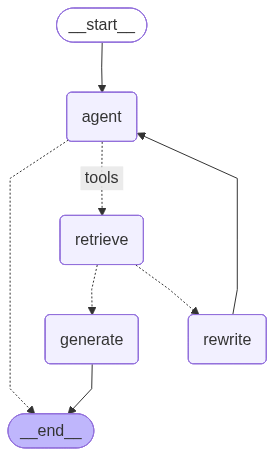

In [29]:
from langgraph.graph import END,StateGraph,START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image,display

workflow=StateGraph(AgentState)

retrieve=ToolNode([retriever_tool])

workflow.add_node("agent",agent)
workflow.add_node("retrieve",retrieve)
workflow.add_node("rewrite",rewrite)
workflow.add_node("generate",generate)

workflow.add_edge(START,"agent")
workflow.add_conditional_edges("agent",tools_condition,{
    "tools":"retrieve",
    END:END,
},)
workflow.add_conditional_edges("retrieve",grade_documents)
workflow.add_edge("generate",END)
workflow.add_edge("rewrite","agent")

graph=workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))




In [30]:
graph.invoke({"messages":"what is machine learning"})

---CALL AGENT---


{'messages': [HumanMessage(content='what is machine learning', additional_kwargs={}, response_metadata={}, id='f23ef376-5713-456a-9177-db6184b4a51d'),
  AIMessage(content='**Machine learning (ML)** is a branch of artificial intelligence (AI) that focuses on building systems that can learn from data, identify patterns, and make decisions or predictions without being explicitly programmed for each specific task.\n\n### Core Idea\n- **Learning from Data:** Instead of writing step‑by‑step rules, you give a computer a large set of examples (the *training data*). The algorithm discovers the underlying relationships in that data.\n- **Model:** The result of this learning process is a *model*—a mathematical representation that can take new inputs and produce outputs (predictions, classifications, recommendations, etc.).\n- **Improvement Over Time:** As more data become available, the model can be retrained or fine‑tuned, often becoming more accurate.\n\n### Main Types of Machine Learning\n\n| 